# Convergence Analysis: Naive MC vs Antithetic vs Control Variate

Comparing three Monte Carlo estimators for a European call option against the Black-Scholes closed-form price. All three are unbiased. They differ in variance.

In [10]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from black_scholes import black_scholes_call
from monte_carlo import european_call_option
from variance_reduction import antithetic_european_call, control_variate_european_call

In [12]:
S0 = 100.0
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0

bs_price = black_scholes_call(S0, K, r, sigma, T)

sim_counts = [1000, 5000, 10000, 50000, 100000, 500000]

mc_prices, mc_ses = [], []
av_prices, av_ses = [], []
cv_prices, cv_ses = [], []

for n in sim_counts:
    mc = european_call_option(S0, K, r, sigma, T, number_of_sims=n)
    av = antithetic_european_call(S0, K, r, sigma, T, number_of_sims=n)
    cv = control_variate_european_call(S0, K, r, sigma, T, number_of_sims=n)

    mc_prices.append(mc['price'])
    mc_ses.append(mc['stderr'])
    av_prices.append(av['price'])
    av_ses.append(av['stderr'])
    cv_prices.append(cv['price'])
    cv_ses.append(cv['stderr'])

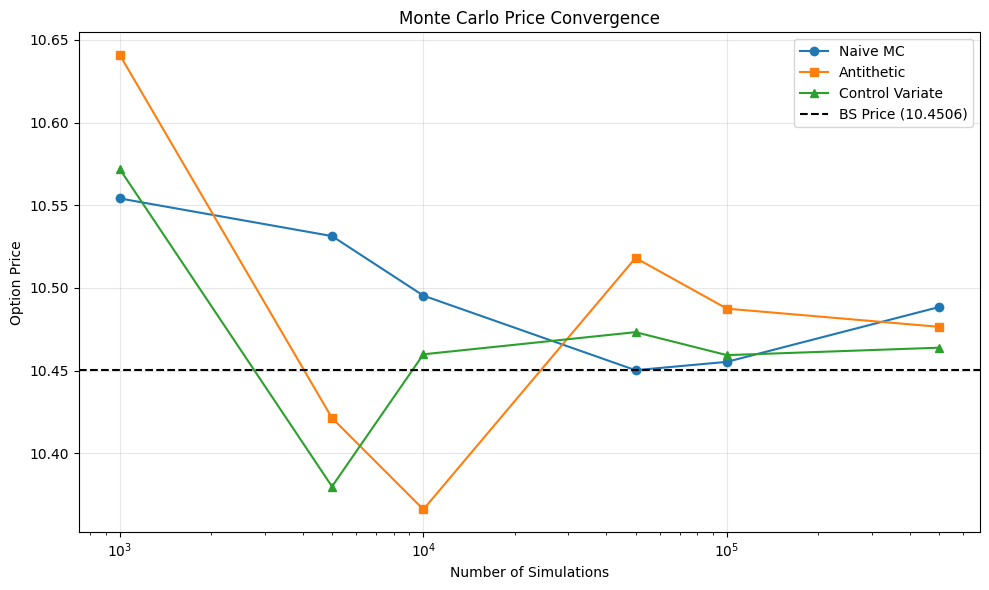

In [13]:
plt.figure(figsize=(10, 6))
plt.semilogx(sim_counts, mc_prices, 'o-', label='Naive MC')
plt.semilogx(sim_counts, av_prices, 's-', label='Antithetic')
plt.semilogx(sim_counts, cv_prices, '^-', label='Control Variate')
plt.axhline(y=bs_price, color='black', linestyle='--', label=f'BS Price ({bs_price:.4f})')
plt.xlabel('Number of Simulations')
plt.ylabel('Option Price')
plt.title('Monte Carlo Price Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/convergence_price.png', dpi=300)
plt.show()

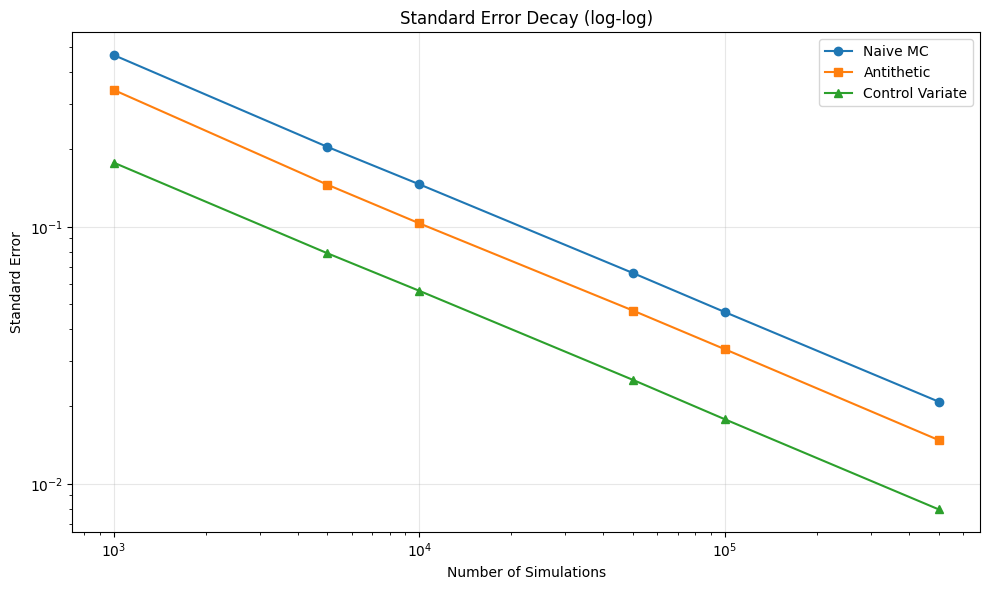

In [14]:
plt.figure(figsize=(10, 6))
plt.loglog(sim_counts, mc_ses, 'o-', label='Naive MC')
plt.loglog(sim_counts, av_ses, 's-', label='Antithetic')
plt.loglog(sim_counts, cv_ses, '^-', label='Control Variate')
plt.xlabel('Number of Simulations')
plt.ylabel('Standard Error')
plt.title('Standard Error Decay (log-log)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/convergence_stderr.png', dpi=300)
plt.show()

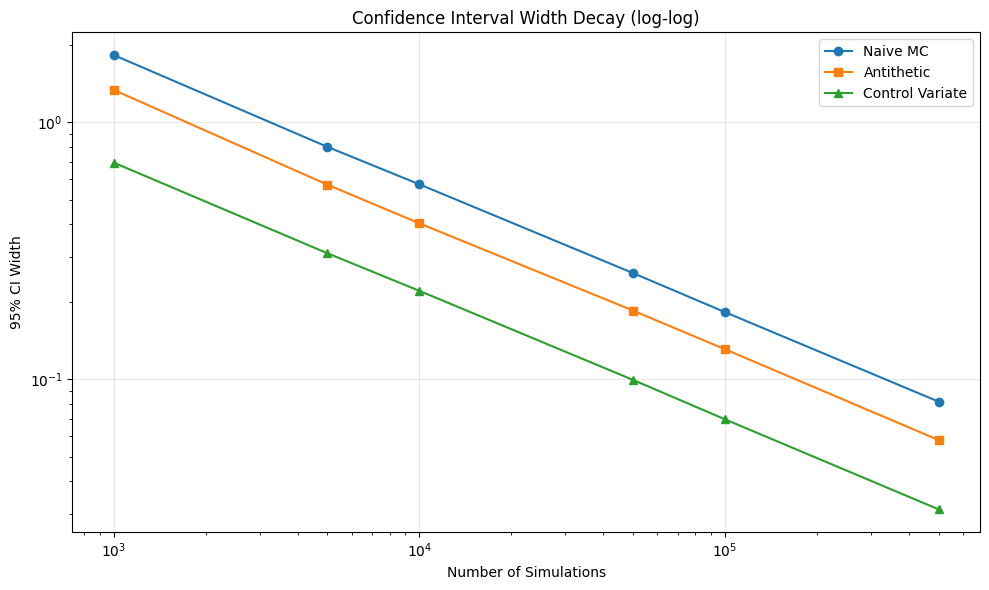

In [15]:
mc_ci = [2 * 1.96 * se for se in mc_ses]
av_ci = [2 * 1.96 * se for se in av_ses]
cv_ci = [2 * 1.96 * se for se in cv_ses]

plt.figure(figsize=(10, 6))
plt.loglog(sim_counts, mc_ci, 'o-', label='Naive MC')
plt.loglog(sim_counts, av_ci, 's-', label='Antithetic')
plt.loglog(sim_counts, cv_ci, '^-', label='Control Variate')
plt.xlabel('Number of Simulations')
plt.ylabel('95% CI Width')
plt.title('Confidence Interval Width Decay (log-log)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/convergence_ci.png', dpi=300)
plt.show()